Imports

In [3]:
from simulated_annealing import *
from data_generator import *
from data_loader import *
from config import *
from annealing_helpers import *
from timetable_phase import *
import matplotlib.pyplot as plt

# Example usage of generator, loader and simulated annealing

### Data generation

In [6]:
stops = 5
time_windows = 24

generate_dummy_data(stops, time_windows)

### Loading the data

In [7]:
P, W = load_data_as_matrices(stops, time_windows)

### Building data

In [8]:
data = build_problem_data(P, C, R, alpha=ALPHA, beta=BETA)

### Running simulated annealing

In [9]:
initial_temp = 10.0
min_temp = 1e-3
cooling_rate = 0.999
max_iter = 1000
log_every = 10

results = run_schedule_optimization(data, initial_temp, min_temp, cooling_rate, max_iter, log_every)

### Interpreting the results

In [10]:
print_results(results)

                 --- Annealing Results ---

           Initial frequencies:   Hourly demands:   Best solution:
Hour: 0          Freq: 1          Demand: 15          Freq: 0
Hour: 1          Freq: 1          Demand: 10          Freq: 1
Hour: 2          Freq: 1          Demand: 13          Freq: 0
Hour: 3          Freq: 1          Demand: 14          Freq: 0
Hour: 4          Freq: 5          Demand: 163          Freq: 2
Hour: 5          Freq: 4          Demand: 138          Freq: 2
Hour: 6          Freq: 15          Demand: 574          Freq: 7
Hour: 7          Freq: 12          Demand: 443          Freq: 4
Hour: 8          Freq: 11          Demand: 433          Freq: 6
Hour: 9          Freq: 5          Demand: 178          Freq: 2
Hour: 10          Freq: 5          Demand: 165          Freq: 2
Hour: 11          Freq: 4          Demand: 128          Freq: 2
Hour: 12          Freq: 4          Demand: 127          Freq: 2
Hour: 13          Freq: 5          Demand: 170          Freq: 2
Hour

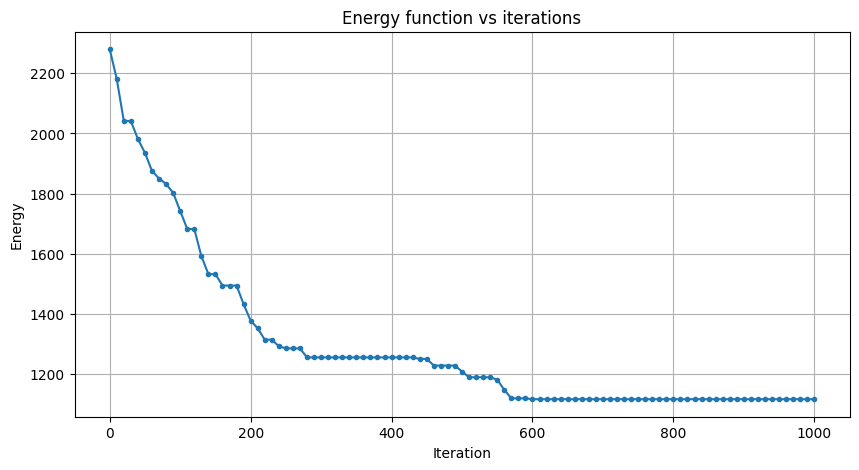

In [11]:
xs, ys = zip(*results["log"])
plt.figure(figsize=(10, 5))
plt.plot(xs, ys, '.-')
plt.xlabel('Iteration')
plt.ylabel('Energy')
plt.title('Energy function vs iterations')
plt.grid(True)
plt.show()

In [12]:
timetable_df = generate_timetable(results, W)

In [14]:
print("\nGotowy rozkład jazdy (wycinek pierwszych 15 odjazdów):")
        # Wyświetlamy ładnie w konsoli bez indeksów
print(timetable_df.head(40).to_string(index=False))

# 4. Zapis do pliku CSV
os.makedirs("data/output", exist_ok=True)
output_file = "data/output/final_timetable.csv"
timetable_df.to_csv(output_file, index=False)
print(f"\n✅ Sukces! Pełny rozkład zapisano pomyślnie do pliku: {output_file}")


Gotowy rozkład jazdy (wycinek pierwszych 15 odjazdów):
 TripID  Stop  DepartureTime_Min ClockTime  HourWindow
      1     1               90.0     01:30           1
      1     2               94.0     01:34           1
      1     3               96.0     01:36           1
      1     4              101.0     01:41           1
      1     5              104.0     01:44           1
      2     1              255.0     04:15           4
      2     2              259.0     04:19           4
      2     3              261.0     04:21           4
      2     4              266.0     04:26           4
      2     5              269.0     04:29           4
      3     1              285.0     04:45           4
      3     2              289.0     04:49           4
      3     3              291.0     04:51           4
      3     4              296.0     04:56           4
      3     5              299.0     04:59           4
      4     1              315.0     05:15           5
      4  